In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [3]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
    

In [4]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_b(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, b_fields: np.ndarray, d, erange
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(b_fields):
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,e], unit='G'), pi.SystemAtom(basis2).set_magnetic_field([0,0,e], unit='G')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um')
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [5]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)
channel=3

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [6]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s = np.arange(-j1_0, j1_0 + 1)
mj2_0s = np.arange(-j2_0, j2_0 + 1)
mj1, mj2 = j1_0, j2_0
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
mj1_1s = np.arange(-j1_1, j1_1 + 1)
mj2_1s = np.arange(-j2_1, j2_1 + 1)
mj1_1, mj2_1 = j1_1, j2_1
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

In [7]:


defect = c['defect']
minb = 0
maxb = 18.266780246710454
num=500
magnetic_fields = np.linspace(minb,maxb,num)
magnetic_fields_nums = enumerate(magnetic_fields)
nums_b_fields_sub = list(magnetic_fields_nums)[::2]
b_fields_sub = list(magnetic_fields)[::2]
r = 50000
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=j2_0-1)

bfield = 0  # Gauss
erange = abs(defect + defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}

pairs = get_system_pair_list_b(ket1, ket2, b_fields_sub, r, erange)
system_pairs_dict[r] = pairs[0]
states_num = pairs[1]


print(system_pairs_dict)

{50000: [SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F_7/2,-7/2⟩ ... |Rb:59,S_1/2,1/2; Cs:57,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:56,F

In [22]:
bs = np.linspace(4, 20, 400)

bmax = 10
magnetic_fields = bs
magnetic_fields_nums = enumerate(magnetic_fields)
r = 5000

bfield = 0  # Gauss
erange = abs(defect + defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}

pairs = get_system_pair_list_b(ket1, ket2, magnetic_fields, r, erange)
system_pairs = pairs[0]
states_num = pairs[1]


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


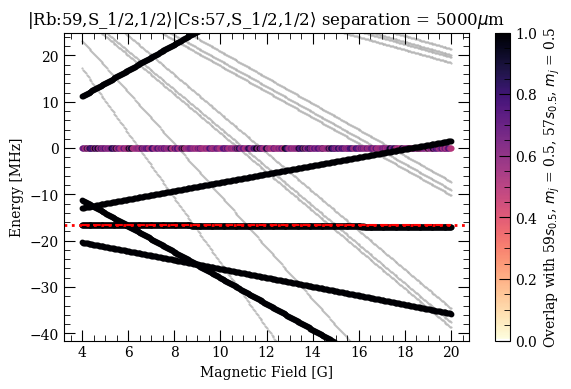

In [25]:
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separation {r} $\mu$m')
# ax.set_ylim(-0.01, 0.01)

# system_atom = system_atom_dict[efield]
pair_energy = ket1_energy + ket2_energy

system_pairs = system_pairs
energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    


# ax.plot(e_fields_sub, energies)
for x, es in zip(bs, energies):
    plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)

plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')

plt.tight_layout()
energy_lim = abs(defect + defect)
offset=defect/2
min_energy = -energy_lim+offset
max_energy = energy_lim+offset
plt.title(fr'{str(ket1)}{str(ket2)} separation = {r}$\mu$m')
plt.ylim(min_energy, max_energy)
# plt.xlim(2, 2.7)
plt.ylabel(f"Energy [{energy_unit}]")
plt.xlabel("Magnetic Field [G]")
min_overlap = 0.5

energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
energies_dict_1 = {f'mjs1{mj1_1}{mj2_1}': [] for mj1_1 in mj1_1s for mj2_1 in mj2_1s}


bs = magnetic_fields

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps0 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]

        energies0=[]

        for x, es, os in zip(bs, energies, overlaps0):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    es[inds],
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies0 = np.append(energies0, es[inds])
                print(len(es[inds]))

            
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies0
                

for mj1_1 in mj1_1s:
    for mj2_1 in mj2_1s:
        ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=mj1_1)
        ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=mj2_1)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_1, ket2_1]) for system in system_pairs]

        energies1=[]
        for x, es, os in zip(bs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    es[inds],
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
        energies_dict_1[f'mjs1{mj1_1}{mj2_1}'] = energies1
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channel zeemans\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\to {orbs[l1_1]}{orbs[l2_1]}\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)
pd.DataFrame(energies_dict_0).to_csv(datapath + f'{n1_0, n2_0}, index0')
pd.DataFrame(energies_dict_1).to_csv(datapath + f'{n1_1, n2_1}, index1')

fig.colorbar(scat, ax=ax, label=fr"Overlap with {ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$ = {ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$ = {ket2.m}")
plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
plt.show()
# fig.savefig(path + f'level pairstate sep{r}.png')

In [ ]:
print(len(energies_dict_0))

4


-0.5 -0.5
-0.5 0.5
0.5 -0.5
0.5 0.5


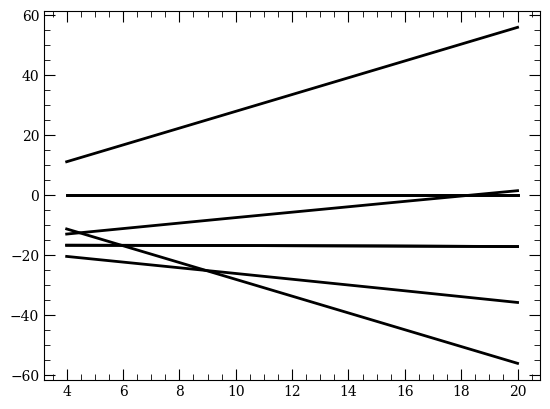

In [26]:
plt.figure()
for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        
        plt.plot(bs, energies_dict_0[f'mjs0{mj1_0}{mj2_0}'], label=f'0', c='0', linewidth = 2)
        print(mj1_0, mj2_0)

for mj1_1 in mj1_1s:
    for mj2_1 in mj2_1s:
        plt.plot(bs, energies_dict_1[f'mjs1{mj1_1}{mj2_1}'], label=f'1', c='0', linewidth = 2)

plt.show()

<BarContainer object of 1 artists>
(250, 10)


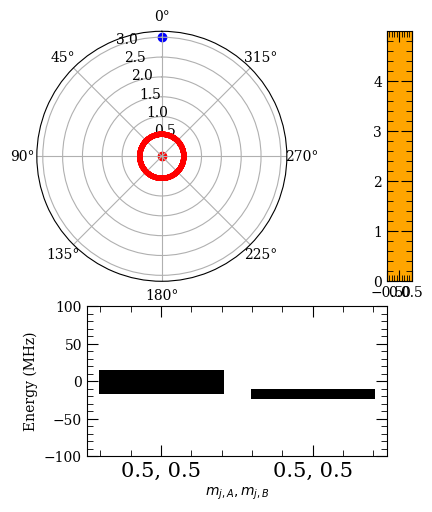

In [49]:


fig = plt.figure(figsize=(5,5))
ax=[]
x_tick_labels = [f'{ket1.m}, {ket2.m}', f'{ket1_1.m}, {ket2_1.m}' ]

ax.append(fig.add_axes([.2, .1, .6, .3]))
ax.append(fig.add_axes([.1, .45, .5, .5], projection='polar'))
ax.append(fig.add_axes([.8, .45, .05, .5]))


t0 = 1
x0 = np.linspace(t0-.4, t0+.4, 2)
thetas = np.linspace(0, 2*np.pi)
t1 = 2
x1 = np.linspace(t1-.4, t1+.4, 2)

ax[0].set_xlabel(r'$m_{j,A}, m_{j,B}$')
ax[0].set_ylabel(f"Energy ({energy_unit})")
ax[0].set_xticks([t0, t1])
ax[0].set_xticklabels(x_tick_labels, fontsize=15)
# ax[0].set(ylim=[min(np.array([energies0, energies1]).flatten()), max(np.array([energies0, energies1]).flatten())])
ax[0].set(ylim=[-100, 100])


ax[2].margins(0, 0)
ax[1].set_theta_zero_location("N")

xdef = 1.5 * np.ones(2)

ax[1].set_rmax(10)
ax[1].set_rmin(0)
def R_c(c3k, delta):
    return (c3k/delta)**(1/3)

# ax.legend()
# plt.show()
artists = []
for i in range(len(bs)):
    containers = []
    for mj1_0 in mj1_0s:
        for mj2_0 in mj2_0s:
            
            line0 = ax[0].plot(x0, energies_dict_0[f'mjs0{mj1_0}{mj2_0}'][i] * np.ones_like(x0), label=f'0', c='0', linewidth = 2)
            containers += line0

    for mj1_1 in mj1_1s:
        for mj2_1 in mj2_1s:
            line1 = ax[0].plot(x1, energies_dict_1[f'mjs1{mj1_1}{mj2_1}'][i] * np.ones_like(x1), label=f'1', c='0', linewidth = 2)
            containers += line1
    
    # linedef = ax[0].plot(xdef, [energies0[i], energies1[i]], c='b')
    bplot = ax[2].bar(0, bs[i], color='orange', width=1)

    # annotate = ax.annotate("",
    #         xy=(xdef, energies1[0]),xytext=(xdef, energies0[1]), textcoords='data',
    #         arrowprops=dict(arrowstyle="<->",
    #                         connectionstyle="arc3", color='r', lw=2),
    #         )

    circle = ax[1].plot(thetas, R_c(c['c3k'], abs(energies0[i] - energies1[i])) * np.ones_like(thetas), color = 'r')
    # circ = plt.Circle((0, 0), R_c(c['c3k'], abs(energies0[i] - energies1[i])), color='r', fill=False)
    # circle = [ax[1].add_patch(circ)]
    # print(line0)
    containers += circle + [bar for bar in bplot.patches]
    # print(containers)

    artists.append(containers)
print(bplot)
# artists = np.array(artists).flatten()
print(np.shape(artists))
ax[1].scatter(0,0, c='r')
ax[1].scatter(0,3, c='b')
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval = 80)
print(ani)
plt.show()
ani.save(filename= fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\anim.gif', writer='pillow')

